# Skin Lesion Classification using CNN

In this notebook, we will build a Convolutional Neural Network to classify skin lesion images from the HAM10000 dataset.

This is a real Medical AI workflow and directly connects to MobileSkinXAI.

## Learning Objectives

- Load real dermoscopic images
- Prepare image paths and labels
- Encode skin lesion classes
- Split data into training and validation sets
- Build a CNN model
- Train and evaluate the model
- Visualize accuracy and loss

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

2026-06-27 17:01:45.025257: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782579705.247680      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782579705.311096      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782579705.809341      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782579705.809384      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782579705.809387      16 computation_placer.cc:177] computation placer alr

## Step 1: Load HAM10000 Metadata

The metadata file contains image IDs and diagnosis labels.

In [2]:
dataset_path = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"

metadata_path = os.path.join(dataset_path, "HAM10000_metadata.csv")

df = pd.read_csv(metadata_path)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


## Step 2: Define Image Folders

HAM10000 images are stored in two folders, so we search both folders for each image.

In [3]:
image_folders = [
    os.path.join(dataset_path, "HAM10000_images_part_1"),
    os.path.join(dataset_path, "HAM10000_images_part_2")
]

def find_image_path(image_id):
    filename = image_id + ".jpg"

    for folder in image_folders:
        path = os.path.join(folder, filename)

        if os.path.exists(path):
            return path

    return None

df["image_path"] = df["image_id"].apply(find_image_path)

df[["image_id", "dx", "image_path"]].head()

,image_id,dx,image_path
0,ISIC_0027419,bkl,/kaggle/input/datasets/kmader/skin-cancer-mnis...
1,ISIC_0025030,bkl,/kaggle/input/datasets/kmader/skin-cancer-mnis...
2,ISIC_0026769,bkl,/kaggle/input/datasets/kmader/skin-cancer-mnis...
3,ISIC_0025661,bkl,/kaggle/input/datasets/kmader/skin-cancer-mnis...
4,ISIC_0031633,bkl,/kaggle/input/datasets/kmader/skin-cancer-mnis...


## Step 3: Select a Smaller Sample

HAM10000 is large, so for beginner practice we will use a smaller sample.

This makes training faster in Kaggle.

In [4]:
sample_df = df.sample(
    n=2000,
    random_state=42
).reset_index(drop=True)

sample_df["dx"].value_counts()

dx
nv       1337
bkl       228
mel       224
bcc        93
akiec      69
df         28
vasc       21
Name: count, dtype: int64

## Step 4: Load and Resize Images

CNN models require images to have the same size.

We resize all images to 64 × 64 for faster training.

In [5]:
IMG_SIZE = 64

images = []
labels = []

for _, row in sample_df.iterrows():
    image = cv2.imread(row["image_path"])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    images.append(image)
    labels.append(row["dx"])

X = np.array(images)
y = np.array(labels)

print("Image Data Shape:", X.shape)
print("Labels Shape:", y.shape)

Image Data Shape: (2000, 64, 64, 3)
Labels Shape: (2000,)


## Step 5: Normalize Images

Pixel values range from 0 to 255.

We scale them between 0 and 1 for better neural network training.

In [6]:
X = X.astype("float32") / 255.0

print("Minimum Pixel Value:", X.min())
print("Maximum Pixel Value:", X.max())

Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


## Step 6: Encode Labels

Machine learning models need numerical labels.

We convert diagnosis labels such as `nv`, `mel`, and `bcc` into numbers.

In [7]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)
print("Encoded Labels:", np.unique(y_encoded))

Classes: ['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']
Encoded Labels: [0 1 2 3 4 5 6]


## Step 7: Split Dataset

We split the dataset into:

- Training set
- Validation set

The validation set helps us evaluate model performance on unseen data.

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training Images:", X_train.shape)
print("Validation Images:", X_val.shape)

Training Images: (1600, 64, 64, 3)
Validation Images: (400, 64, 64, 3)


## Step 8: Build CNN Model

The CNN will learn visual features from dermoscopic images.

The final layer has one neuron for each skin lesion class.

In [9]:
num_classes = len(label_encoder.classes_)

model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(num_classes, activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-27 17:02:58.578079: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,103 (2.61 MB)

 Trainable params: 684,103 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## Step 9: Compile Model

For multi-class classification, we use:

- Sparse Categorical Crossentropy
- Adam optimizer
- Accuracy metric

In [10]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Step 10: Train Model

The model learns patterns from the training images.

We use a small number of epochs for beginner practice.

In [11]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.6619 - loss: 1.2216 - val_accuracy: 0.6675 - val_loss: 1.0651
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.6687 - loss: 1.0526 - val_accuracy: 0.6675 - val_loss: 1.0220
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.6681 - loss: 1.0305 - val_accuracy: 0.6675 - val_loss: 0.9594
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.6694 - loss: 0.9913 - val_accuracy: 0.6675 - val_loss: 0.9585
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.6687 - loss: 0.9575 - val_accuracy: 0.6675 - val_loss: 0.9647
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.6694 - loss: 0.9886 - val_accuracy: 0.6675 - val_loss: 0.9193
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.6694 - loss: 0.9593 - val_accuracy: 0.6675 - val_loss: 0.9192
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.6719 - loss: 0.9351 - val_accuracy: 0.6675 - v

## Step 11: Visualize Accuracy and Loss

Training curves help us understand whether the model is learning properly.

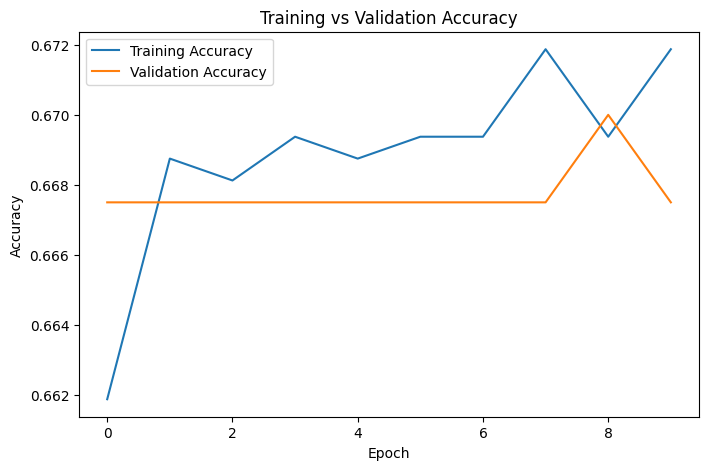

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

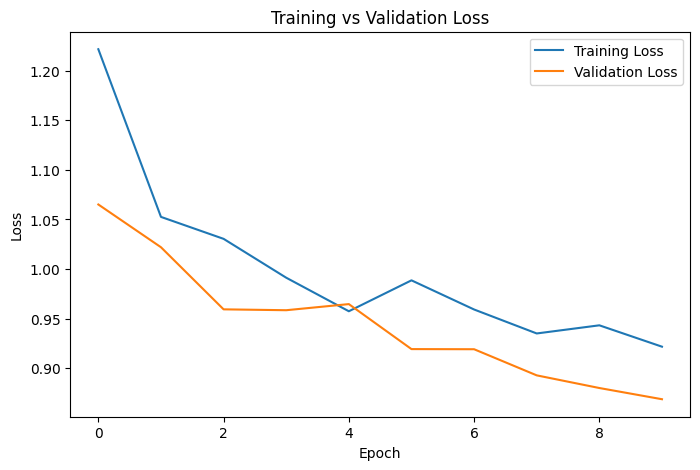

In [13]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Step 12: Evaluate Model

We now generate predictions and evaluate the classifier using precision, recall, and F1-score.

In [14]:
y_pred_probs = model.predict(X_val)

y_pred = np.argmax(y_pred_probs, axis=1)

print(
    classification_report(
        y_val,
        y_pred,
        target_names=label_encoder.classes_
    )
)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
              precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        14
         bcc       0.00      0.00      0.00        19
         bkl       0.00      0.00      0.00        45
          df       0.00      0.00      0.00         6
         mel       0.00      0.00      0.00        45
          nv       0.67      1.00      0.80       267
        vasc       0.00      0.00      0.00         4

    accuracy                           0.67       400
   macro avg       0.10      0.14      0.11       400
weighted avg       0.45      0.67      0.53       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Step 13: Confusion Matrix

The confusion matrix shows which lesion classes were predicted correctly and where the model made mistakes.

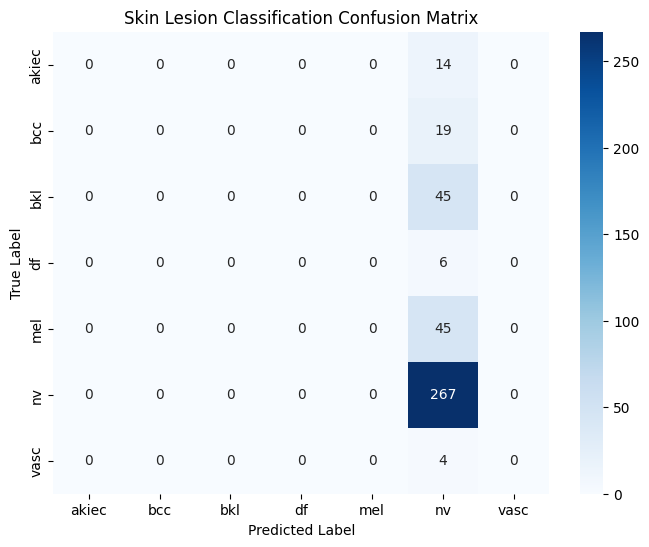

In [15]:
import seaborn as sns

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Skin Lesion Classification Confusion Matrix")

plt.show()

## Step 14: Visualize Predictions

Let's compare predicted labels with actual labels on sample validation images.

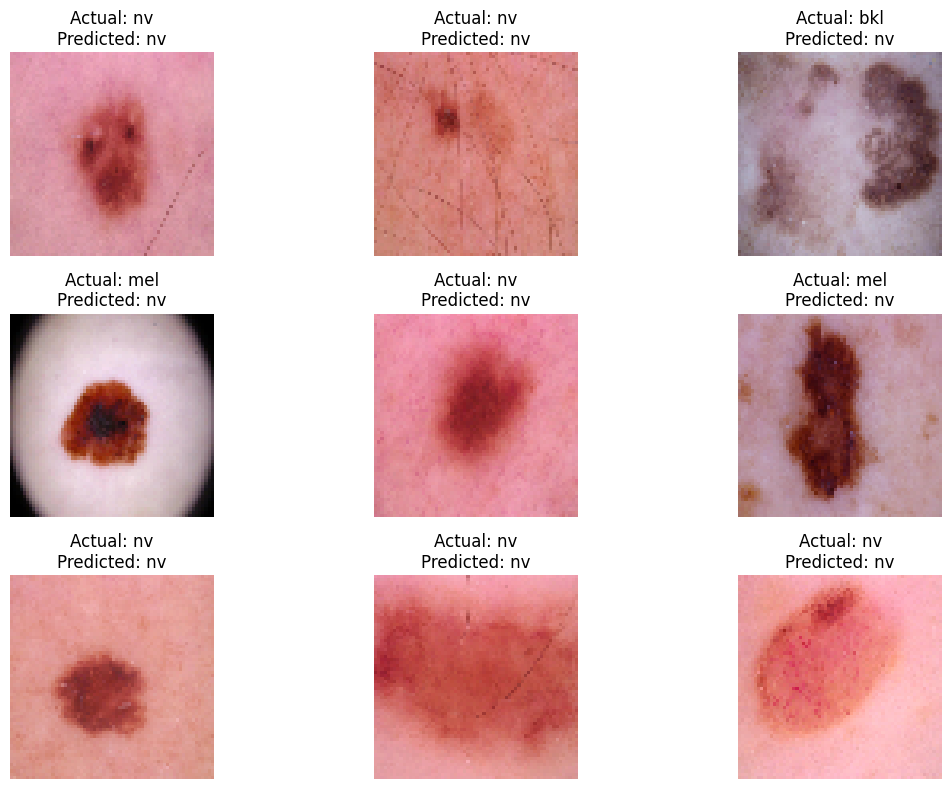

In [16]:
plt.figure(figsize=(12,8))

for i in range(9):
    plt.subplot(3,3,i+1)

    plt.imshow(X_val[i])

    actual = label_encoder.inverse_transform([y_val[i]])[0]
    predicted = label_encoder.inverse_transform([y_pred[i]])[0]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Conclusion

In this notebook, I built a CNN model for skin lesion classification using the HAM10000 dataset.

## What I Learned

- How to load real medical images
- How to resize and normalize skin lesion images
- How to encode diagnosis labels
- How to train a CNN classifier
- How to evaluate a medical image classification model
- How to interpret accuracy, loss, classification report, and confusion matrix

This notebook is an important step toward MobileSkinXAI and future skin cancer classification research.